# PCA application in dow index listed companies

##  Data related 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import yfinance as yf 
import seaborn as sns; sns.set()

In [ ]:
it_tickers = ['AAPL', 'CSCO', 'IBM', 'INTC', 'MMM', 'MSFT', 'VZ']

In [ ]:
data_dj = yf.download('^DJI')['Close']

[*********************100%***********************]  1 of 1 completed


In [ ]:
data_dj.head()

Date
1992-01-02    3172.399902
1992-01-03    3201.500000
1992-01-06    3200.100098
1992-01-07    3204.800049
1992-01-08    3203.899902
Name: Close, dtype: float64

In [ ]:
data = pd.DataFrame([])
for ticker in it_tickers:
    data[ticker]= yf.download(ticker)['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
data.dropna(inplace=True)
data = data[data_dj.index[0]:]

<AxesSubplot:xlabel='Date'>

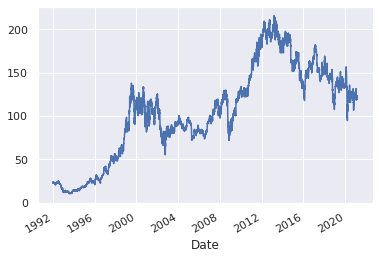

In [ ]:
data['IBM'].plot(label='IBM')
#data_dj.plot(secondary_y=True, label='DJIA')
#plt.legend()

In [ ]:
df = data.apply(lambda x: (x-x.mean())/x.std())
df_corr = df.head().corr()

In [ ]:
df_corr 

,AAPL,CSCO,IBM,INTC,MMM,MSFT,VZ
AAPL,1.000000,0.646972,-0.031920,0.850187,-0.146652,0.577346,0.235705
CSCO,0.646972,1.000000,0.589986,0.876095,0.344795,0.962638,-0.519534
IBM,-0.031920,0.589986,1.000000,0.490864,0.947039,0.674664,-0.882042
INTC,0.850187,0.876095,0.490864,1.000000,0.359192,0.836677,-0.232481
MMM,-0.146652,0.344795,0.947039,0.359192,1.000000,0.457156,-0.764874
MSFT,0.577346,0.962638,0.674664,0.836677,0.457156,1.000000,-0.649085
VZ,0.235705,-0.519534,-0.882042,-0.232481,-0.764874,-0.649085,1.000000


### pca fitting

In [ ]:
from sklearn.decomposition import PCA 

pca = PCA(n_components=7)

In [ ]:
pca.fit(df)

PCA(n_components=7)

In [ ]:
pca.explained_variance_ratio_

array([0.7337924 , 0.1114016 , 0.08614945, 0.03351172, 0.02401217,
       0.00818114, 0.00295152])

In [ ]:
projected = pca.fit_transform(df)

In [ ]:
np.corrcoef(projected[:,0], df['AAPL'])

array([[1.        , 0.83930947],
       [0.83930947, 1.        ]])

In [ ]:
corrMat = pd.DataFrame([])

In [ ]:
for j in range(7):
    tmp = 'pc' + f'{j}'
    corrMat[tmp] = [np.corrcoef(projected[:,j],df[ticker])[0,1] for ticker in df.columns]

In [ ]:
corrMat.index = it_tickers
corrMat

,pc0,pc1,pc2,pc3,pc4,pc5,pc6
AAPL,0.839309,0.480013,-0.200736,-0.035569,0.122321,0.019102,0.090884
CSCO,0.868140,-0.201503,0.380364,0.192179,0.044106,0.148359,0.012810
IBM,0.721424,-0.533555,-0.385363,-0.034268,0.211531,-0.013106,-0.016479
INTC,0.914525,-0.101574,0.335455,0.082416,0.003158,-0.183076,0.021828
MMM,0.860182,0.013377,-0.379762,0.214071,-0.264068,-0.000531,-0.011456
MSFT,0.888246,0.432285,0.052991,-0.042438,0.090955,0.001874,-0.106128
VZ,0.890358,-0.163550,0.100063,-0.375220,-0.168574,0.034645,0.009713


---
# Biplot of Eigenvector 

- plot the first second components of eigenvetors on PCA space (PCA1, PCA2) 
    - $v_{i1}, v_{i2}$ on (PCA1, PCA2) space
    
  $  
  \begin{align*}
    Y_i &= (PCA_i) = v_{i1}X_1 + v_{i2}X_2 + \cdots + v_{ip}X_p \\
    &\text{where} \\
    &\;\;\;\;\;\;\;\ v_{ij} = \text{eigenvector of}\;\; \text{Var}(X)
  \end{align*}
  $
 

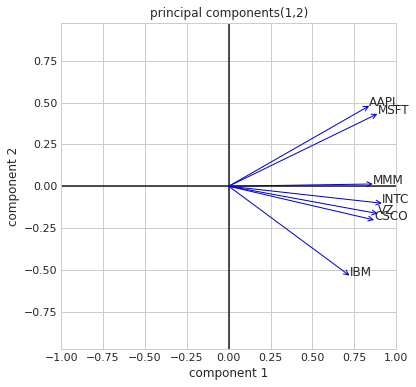

In [ ]:
plt.style.use('seaborn-whitegrid')
fig, ax = plt.subplots(figsize=(6,6))

for ticker in it_tickers:
    draw_vector([0, 0], corrMat.loc[ticker][:2], ax = ax)
    ax.text(corrMat.loc[ticker][:2][0], corrMat.loc[ticker][:2][1], ticker)

ax.axis('equal')
plt.axhline(y=0, c='k')  
plt.axvline(x=0, c='k')
ax.set(xlabel='component 1', ylabel='component 2',
          title='principal components(1,2)', 
      xlim=(-1., 1.), ylim=(-1., 1.));

- as expected, all IT companies are positively correlated with PCA1

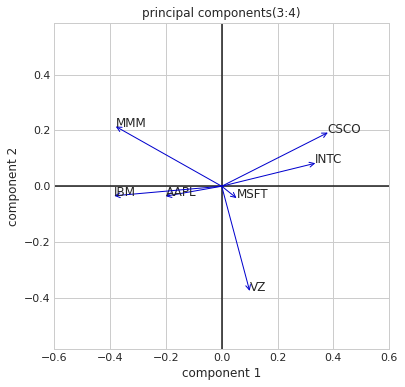

In [ ]:
plt.style.use('seaborn-whitegrid')
fig, ax = plt.subplots(figsize=(6,6))

for ticker in it_tickers:
    draw_vector([0, 0], corrMat.loc[ticker][2:4], ax = ax)
    ax.text(corrMat.loc[ticker][2:4][0], corrMat.loc[ticker][2:4][1], ticker)

ax.axis('equal')
plt.axhline(y=0, c='k')  
plt.axvline(x=0, c='k')
    
ax.set(xlabel='component 1', ylabel='component 2',
          title='principal components(3:4)', 
      xlim=(-0.6, 0.6), ylim=(-0.6, 0.6));

In [ ]:
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops = dict(arrowstyle='->', linewidth=1, shrinkA=0, shrinkB=0, ec='mediumblue')   # https://matplotlib.org/users/annotations_guide.html
    ax.annotate("", v1, v0, arrowprops=arrowprops)